## 0. Imports et configuration

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Reproductibilité
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device utilisé : {device}')
print(f'PyTorch version : {torch.__version__}')

Device utilisé : cuda
PyTorch version : 2.10.0+cu128


## 1. Chargement et exploration des données

In [10]:
# Transformation : normalisation des pixels (moyenne=0.1307, std=0.3081 sur MNIST)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Téléchargement des datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f'Taille dataset train : {len(train_dataset)}')
print(f'Taille dataset test  : {len(test_dataset)}')
print(f'Forme d\'une image   : {train_dataset[0][0].shape}')
print(f'Classes              : {train_dataset.classes}')

Taille dataset train : 60000
Taille dataset test  : 10000
Forme d'une image   : torch.Size([1, 28, 28])
Classes              : ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


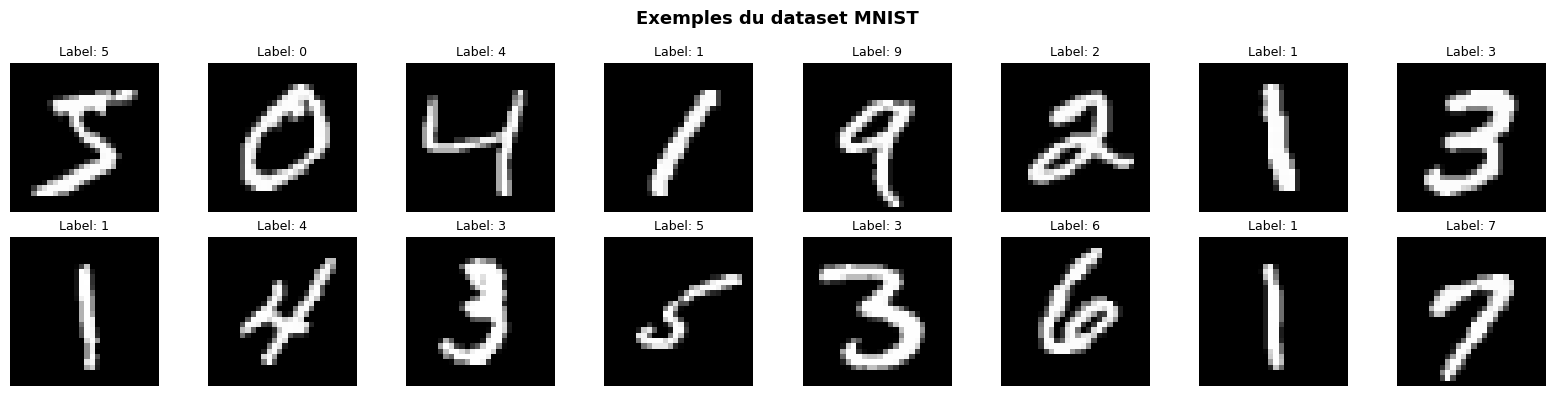

In [11]:
# Visualisation de quelques exemples
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flatten()):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}', fontsize=9)
    ax.axis('off')
plt.suptitle('Exemples du dataset MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

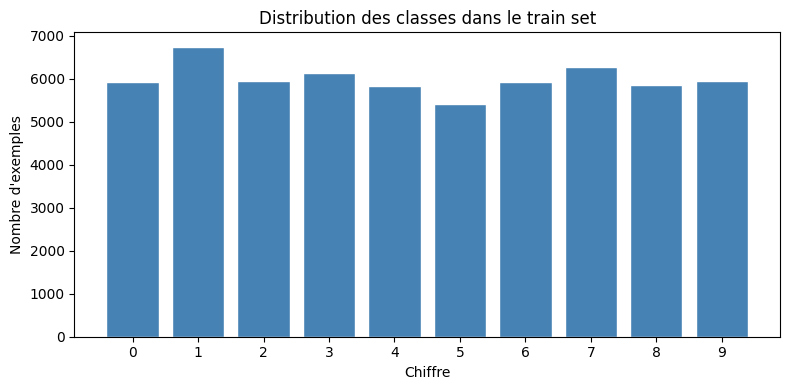

In [12]:
# Distribution des classes
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
plt.figure(figsize=(8, 4))
plt.bar(range(10), [labels.count(i) for i in range(10)], color='steelblue', edgecolor='white')
plt.xlabel('Chiffre')
plt.ylabel('Nombre d\'exemples')
plt.title('Distribution des classes dans le train set')
plt.xticks(range(10))
plt.tight_layout()
plt.show()

## 2. DataLoaders

In [13]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Nombre de batches train : {len(train_loader)}')
print(f'Nombre de batches test  : {len(test_loader)}')

# Vérification d'un batch
images, labels = next(iter(train_loader))
print(f'Forme d\'un batch images : {images.shape}')  # [64, 1, 28, 28]
print(f'Forme d\'un batch labels : {labels.shape}')  # [64]

Nombre de batches train : 938
Nombre de batches test  : 157
Forme d'un batch images : torch.Size([64, 1, 28, 28])
Forme d'un batch labels : torch.Size([64])


## 3. Définition du modèle MLP

Architecture :
- **Entrée** : 784 neurones (28×28 pixels aplatis)
- **Couche cachée 1** : 512 neurones + ReLU + Dropout(0.3)
- **Couche cachée 2** : 256 neurones + ReLU + Dropout(0.3)
- **Couche cachée 3** : 128 neurones + ReLU
- **Sortie** : 10 neurones (une par classe)

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=512, hidden2=256, hidden3=128, num_classes=10):
        super(MLP, self).__init__()
        
        self.network = nn.Sequential(
            # Couche 1
            nn.Linear(input_size, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Couche 2
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Couche 3
            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            
            # Couche de sortie
            nn.Linear(hidden3, num_classes)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)  # Aplatissement : [batch, 1, 28, 28] -> [batch, 784]
        return self.network(x)


# Instanciation du modèle
model = MLP().to(device)

# Résumé de l'architecture
print(model)
print(f'\nNombre total de paramètres : {sum(p.numel() for p in model.parameters()):,}')
print(f'Paramètres entraînables    : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

MLP(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=10, bias=True)
  )
)

Nombre total de paramètres : 568,970
Paramètres entraînables    : 568,970


## 4. Entraînement

In [15]:
# Hyperparamètres
LEARNING_RATE = 0.001
NUM_EPOCHS    = 15

# Fonction de perte et optimiseur
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Scheduler pour réduire le LR si le val_loss stagne
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print(f'Critère  : {criterion}')
print(f'Optimiseur : Adam, lr={LEARNING_RATE}')
print(f'Epochs   : {NUM_EPOCHS}')

Critère  : CrossEntropyLoss()
Optimiseur : Adam, lr=0.001
Epochs   : 15


In [16]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()           # Réinitialiser les gradients
        outputs = model(images)          # Forward pass
        loss = criterion(outputs, labels)# Calcul de la perte
        loss.backward()                  # Backpropagation
        optimizer.step()                 # Mise à jour des poids
        
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    
    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    
    return total_loss / len(loader), 100. * correct / total

In [17]:
# Boucle d'entraînement
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}
best_acc = 0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    
    scheduler.step(test_loss)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    # Sauvegarde du meilleur modèle
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'best_model.pth')
    
    print(f'Epoch [{epoch:2d}/{NUM_EPOCHS}] '
          f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
          f'Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%')

print(f'\n✅ Meilleure précision test : {best_acc:.2f}%')

Epoch [ 1/15] Train Loss: 0.2586 | Train Acc: 92.36% | Test Loss: 0.0996 | Test Acc: 96.87%
Epoch [ 2/15] Train Loss: 0.1310 | Train Acc: 95.88% | Test Loss: 0.0821 | Test Acc: 97.45%
Epoch [ 3/15] Train Loss: 0.1050 | Train Acc: 96.69% | Test Loss: 0.0635 | Test Acc: 97.98%
Epoch [ 4/15] Train Loss: 0.0880 | Train Acc: 97.21% | Test Loss: 0.0742 | Test Acc: 97.85%
Epoch [ 5/15] Train Loss: 0.0815 | Train Acc: 97.43% | Test Loss: 0.0643 | Test Acc: 98.01%
Epoch [ 6/15] Train Loss: 0.0701 | Train Acc: 97.74% | Test Loss: 0.0635 | Test Acc: 97.90%
Epoch [ 7/15] Train Loss: 0.0651 | Train Acc: 97.93% | Test Loss: 0.0581 | Test Acc: 98.32%
Epoch [ 8/15] Train Loss: 0.0583 | Train Acc: 98.11% | Test Loss: 0.0561 | Test Acc: 98.28%
Epoch [ 9/15] Train Loss: 0.0528 | Train Acc: 98.27% | Test Loss: 0.0555 | Test Acc: 98.27%
Epoch [10/15] Train Loss: 0.0506 | Train Acc: 98.31% | Test Loss: 0.0543 | Test Acc: 98.33%
Epoch [11/15] Train Loss: 0.0462 | Train Acc: 98.53% | Test Loss: 0.0569 | Test 

## 5. Évaluation et visualisation des résultats

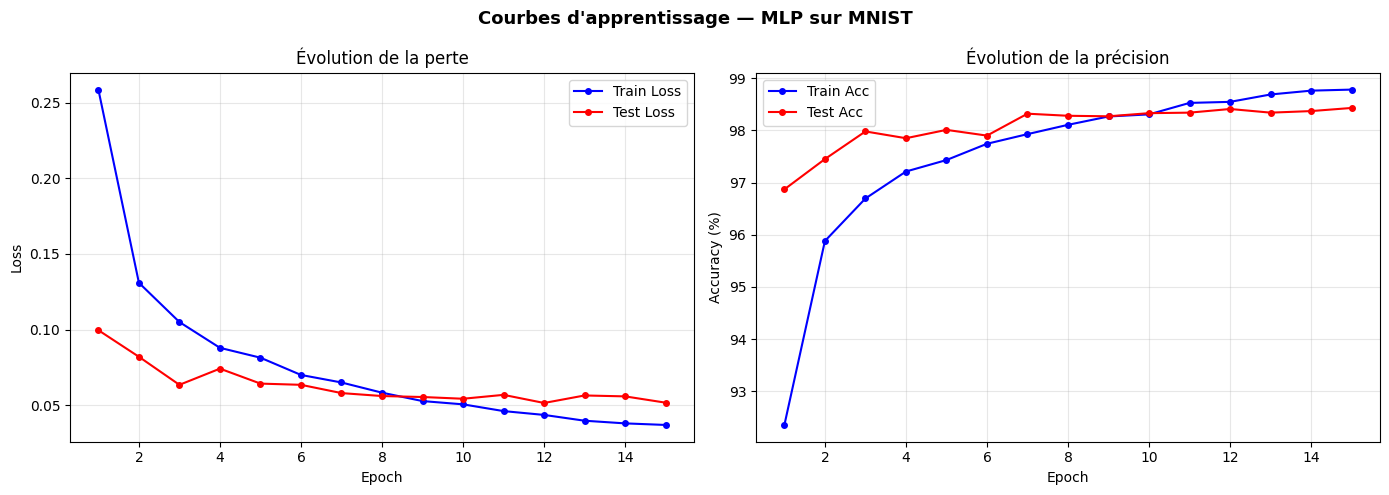

In [18]:
# Courbes d'apprentissage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, NUM_EPOCHS + 1)

ax1.plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, history['test_loss'],  'r-o', label='Test Loss',  markersize=4)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Évolution de la perte')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc', markersize=4)
ax2.plot(epochs_range, history['test_acc'],  'r-o', label='Test Acc',  markersize=4)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Évolution de la précision')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Courbes d\'apprentissage — MLP sur MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

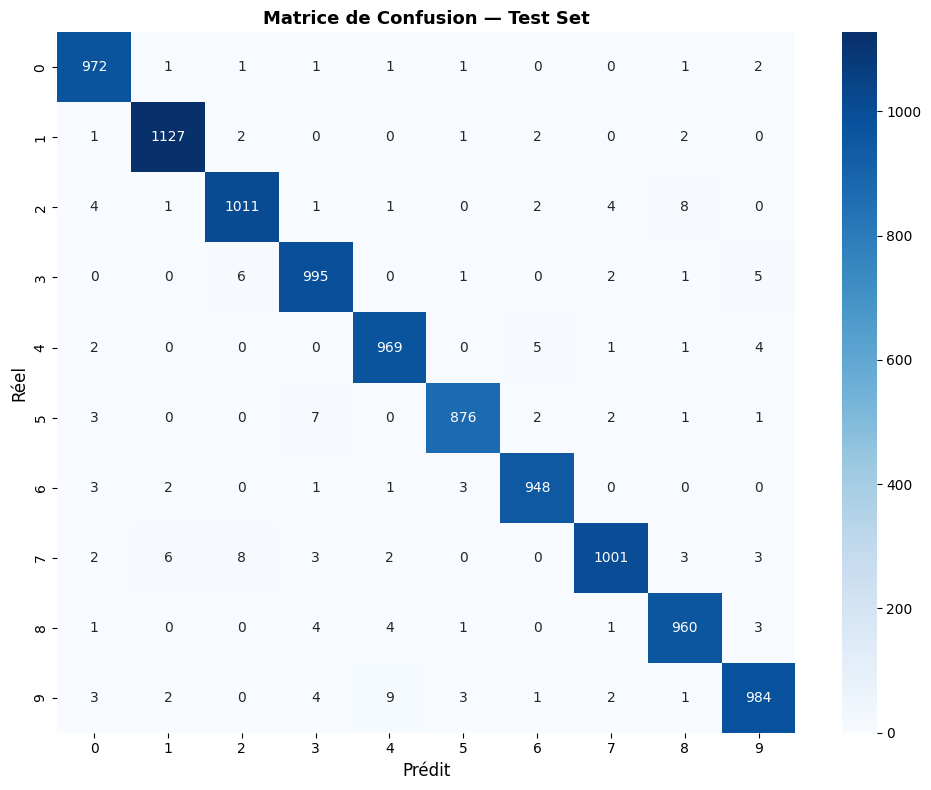


Rapport de Classification :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.98      0.99      0.98       982
           5       0.99      0.98      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.97      0.98      1028
           8       0.98      0.99      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [19]:
# Matrice de confusion
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.title('Matrice de Confusion — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nRapport de Classification :')
print(classification_report(all_labels, all_preds, target_names=[str(i) for i in range(10)]))

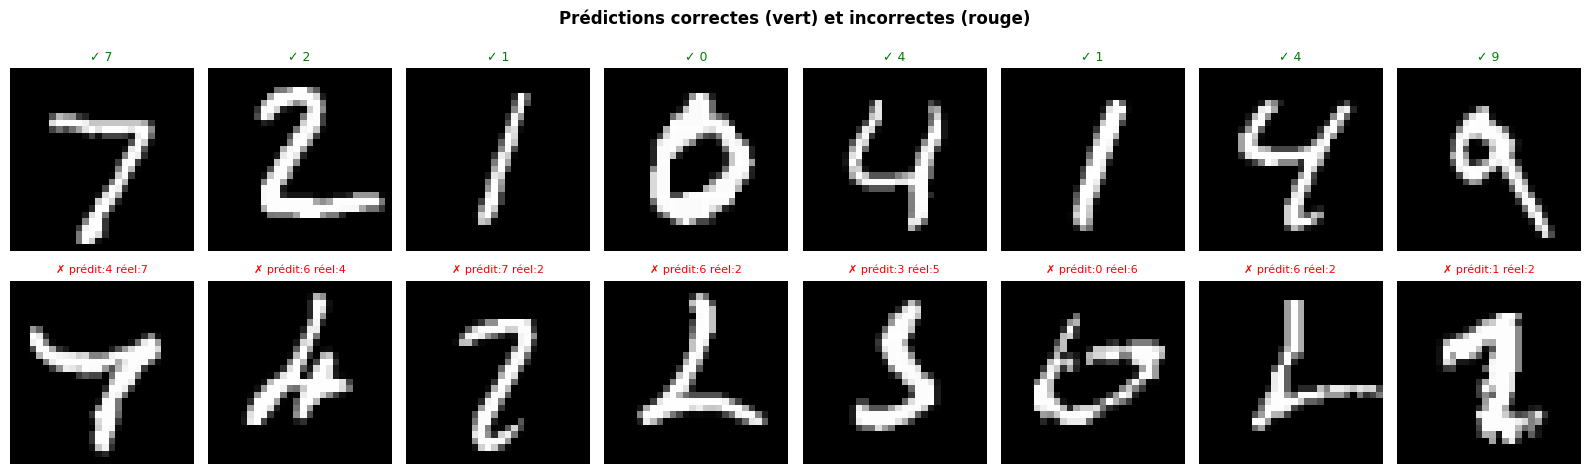

In [20]:
# Visualisation des prédictions : exemples corrects et incorrects
all_preds   = np.array(all_preds)
all_labels  = np.array(all_labels)

errors_idx  = np.where(all_preds != all_labels)[0]
correct_idx = np.where(all_preds == all_labels)[0]

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
fig.suptitle('Prédictions correctes (vert) et incorrectes (rouge)', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes[0]):
    idx = correct_idx[i]
    img, _ = test_dataset[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'✓ {all_preds[idx]}', color='green', fontsize=9)
    ax.axis('off')

for i, ax in enumerate(axes[1]):
    idx = errors_idx[i]
    img, _ = test_dataset[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'✗ prédit:{all_preds[idx]} réel:{all_labels[idx]}', color='red', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()